In [ ]:
import cv2
import numpy as np
import os

DATA_DIR = 'data/real'
IMG_SIZE = 96

Load SOCOFing data from kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruizgara/socofing")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'socofing' dataset.
Path to dataset files: /kaggle/input/socofing


In [ ]:
import os
import shutil

# 1. Download latest version (Saves to the Kaggle Cache)
path = kagglehub.dataset_download("ruizgara/socofing")

# 2. Define Source Path: The location of the images within the cache
SOURCE_DIR = os.path.join(path, "SOCOFing", "Real")

print(f"Kaggle cache path root: {path}")
print(f"Kaggle cache path for 'real' images: {SOURCE_DIR}")
print(f"Project destination path: {DATA_DIR}")

# 3. Ensure the destination folder in your project is created
os.makedirs(DATA_DIR, exist_ok=True)
print("Destination directory ensured.")

# 4. Copy files from cache to project directory
print("Starting file COPY from cache to project directory...")
copied_count = 0

if not os.path.isdir(SOURCE_DIR):
    print("\nERROR: Source directory not found in cache. Did a previous 'shutil.move' empty it?")
    print("Please manually check the cache path printed above.")
else:
    for filename in os.listdir(SOURCE_DIR):
        source_path = os.path.join(SOURCE_DIR, filename)
        dest_path = os.path.join(DATA_DIR, filename)

        if filename.endswith(".BMP") and os.path.isfile(source_path):
            shutil.copy2(source_path, dest_path)
            copied_count += 1

    print(f"\nSuccessfully copied {copied_count} files to {DATA_DIR}.")

Using Colab cache for faster access to the 'socofing' dataset.
Kaggle cache path root: /kaggle/input/socofing
Kaggle cache path for 'real' images: /kaggle/input/socofing/SOCOFing/Real
Project destination path: data/real
Destination directory ensured.
Starting file COPY from cache to project directory...

Successfully copied 6000 files to data/real.


Preprocess the images and labels

In [ ]:
from matplotlib import pyplot as plt

# Step 1: Greyscale Conversion & Resizing
def preprocess_basic(image, img_size=IMG_SIZE):
  img_resized = cv2.resize(image, (img_size, img_size))
  return img_resized

# Step 2: Noise Reduction & Smoothing
def denoise_image(image):
  return cv2.bilateralFilter(image, 5, 50, 50)

# Step 3: Adaptive contrast (CLAHE)
def enhance_contrast(image):
  clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
  image_uint8 = np.uint8(image * 255) if image.max() <= 1.0 else np.uint8(image)
  enhanced = clahe.apply(image_uint8)
  return enhanced / 255.0

# Step 4: Optional light sharpening (emphasize ridges)
def sharpen_image(image):
  kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
  sharpened = cv2.filter2D(image, -1, kernel)
  return np.clip(sharpened, 0, 1)

# Step 5: Normalization (0–1 scale)
def normalize_image(image):
  return image / 255.0

# Preprocess pipeline
def preprocess_image(image_path):
  img = preprocess_basic(image_path)
  img = denoise_image(img)
  img = normalize_image(img)
  img = enhance_contrast(img)
  img = sharpen_image(img)
  return img

Detect ridges and valleys


In [ ]:
from skimage.morphology import skeletonize

def count_ridges_and_valleys(image, threshold=0.1, min_line_length=30):

  img_uint8 = np.uint8(image * 255)

  def gabor_filter_bank(img, frequencies=[0.1,0.2,0.3]):
    thetas = np.linspace(0, np.pi, 8, endpoint=False)
    accum = np.zeros_like(img, dtype=np.float32)
    for theta in thetas:
      for freq in frequencies:
        lam = max(2, int(1.0/(freq+1e-6)))
        kernel = cv2.getGaborKernel((21,21), 4.0, theta, lam, 0.5, 0, ktype=cv2.CV_32F)
        fimg = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kernel)
        accum += np.abs(fimg)
    accum = cv2.normalize(accum, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return accum

  gabor = gabor_filter_bank(img_uint8)
  combined = cv2.addWeighted(img_uint8, 0.5, gabor, 0.5, 0)

  binary = cv2.adaptiveThreshold(combined, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
  cv2.THRESH_BINARY, 35, 2)

  rows, cols = binary.shape
  row_trans = sum(np.sum(binary[r, :-1] != binary[r, 1:]) for r in range(rows))
  col_trans = sum(np.sum(binary[:-1, c] != binary[1:, c]) for c in range(cols))
  avg_trans_per_line = (row_trans/rows + col_trans/cols) / 2.0
  rtvtr = float(avg_trans_per_line) / 100.0

  white_frac = np.mean(binary==255)
  if white_frac < 0.5:
    bin_for_skel = (binary==0).astype(np.uint8)
  else:
    bin_for_skel = (binary==255).astype(np.uint8)

  skel = skeletonize(bin_for_skel)
  skel = (skel.astype(np.uint8) * 255)

  nb_components, labels, stats, centroids = cv2.connectedComponentsWithStats(skel, connectivity=8)
  white_line_count = sum(1 for i in range(1, nb_components) if stats[i, cv2.CC_STAT_AREA] >= min_line_length)

  return {'rtvtr': rtvtr, 'white_line_count': white_line_count}

Load and preprocess all images in the directory

In [ ]:
# Load and preprocess all images in the directory
def load_data_enhanced(data_dir):
    """Loads and preprocesses all images in a directory."""
    data = []
    print("Starting enhanced preprocessing...")

    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    for filename in os.listdir(data_dir):
        if filename.endswith('.BMP'):
            path = os.path.join(data_dir, filename)
            subject_id = int(filename.split('__')[0])

            # Extract label and subject ID (assuming 'ID_F' or 'ID_M' naming)
            if '_F_' in filename or '__F_' in filename:
                label = 1
            elif '_M_' in filename or '__M_' in filename:
                label = 0
            else:
                raise ValueError(f"Cannot extract gender from filename: {filename}")

            # Process image
            original_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            processed_img = preprocess_image(original_img)

            counts = count_ridges_and_valleys(processed_img)
            rtvtr_count = counts['rtvtr']
            white_line_count = counts['white_line_count']

            # Store data
            data.append((processed_img, label, rtvtr_count, white_line_count, subject_id, filename))

    print(f"Finished loading {len(data)} enhanced images.")
    return data

See sample images after enhancement

In [ ]:
all_data = load_data_enhanced(DATA_DIR)

# Get the first 10 examples (or fewer if less than 10 files were loaded)
display_data = all_data[13:14]

print("\n10 EXAMPLE DATA POINTS")

# Display the images and data - corrected unpacking
#for i, (proc_img, label, rtvtr_count, white_line_count, sub_id, fname) in enumerate(display_data):
for i, (orig_img, proc_img, label, rtvtr_count, white_line_count, sub_id, fname) in enumerate(display_data):
    # Print the metadata
    print(f"\n - Example {i+1} ({fname})")
    print(f"Subject ID: {sub_id} | Label (Gender): {'Female' if label == 1 else 'Male'} | Ridge Count (RTVTR): {rtvtr_count} | White Line Count: {white_line_count}")

    # Create the plot for original vs. processed image
    fig, axes = plt.subplots(1, 2, figsize=(1, 2))

    # Plot 1: Original Image
    axes[0].imshow(orig_img, cmap='gray')
    axes[0].set_title(f'Original (Sub ID: {sub_id})')
    axes[0].axis('off')

    # Plot 2: Processed Image
    axes[1].imshow(proc_img, cmap='gray')
    axes[1].set_title(f'Processed (RTVTR: {rtvtr_count:.2f}, White Lines: {white_line_count})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Starting enhanced preprocessing...
Finished loading 6000 enhanced images.

10 EXAMPLE DATA POINTS


ValueError: not enough values to unpack (expected 7, got 6)

Splitting data into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

# Load enhanced dataset
dataset = load_data_enhanced(DATA_DIR)

# Preview a few samples
print("\nSample data check:")
for i, (img, label, rtvtr_count, white_line_count, subject_id, filename) in enumerate(dataset[:20]):
    gender = "Female" if label == 1 else "Male"
    print(f"Subject ID = {subject_id}, Label = {gender}, Image shape = {img.shape}, RTVTR_count = {rtvtr_count}, White Lines Count = {white_line_count}")

# Unpack data
images = np.array([item[0] for item in dataset])
labels = np.array([item[1] for item in dataset])
rtvtr_counts = np.array([item[2] for item in dataset])
white_line_counts = np.array([item[3] for item in dataset])
subject_ids = np.array([item[4] for item in dataset])

# Combine extra numerical features
extra_features = np.column_stack((rtvtr_counts, white_line_counts))

# Reshape images for CNN input
images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Split everything consistently
X_train, X_temp, y_train, y_temp, feat_train, feat_temp = train_test_split(
    images, labels, extra_features, test_size=0.3, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test, feat_val, feat_test = train_test_split(
    X_temp, y_temp, feat_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set size:   {X_train.shape[0]} images")
print(f"Validation set size: {X_val.shape[0]} images")
print(f"Testing set size:    {X_test.shape[0]} images")


Starting enhanced preprocessing...
Finished loading 6000 enhanced images.

Sample data check:
Subject ID = 207, Label = Male, Image shape = (96, 96), RTVTR_count = 0.25229166666666664, White Lines Count = 8
Subject ID = 374, Label = Male, Image shape = (96, 96), RTVTR_count = 0.2858333333333334, White Lines Count = 3
Subject ID = 64, Label = Male, Image shape = (96, 96), RTVTR_count = 0.33859375, White Lines Count = 1
Subject ID = 546, Label = Male, Image shape = (96, 96), RTVTR_count = 0.23682291666666663, White Lines Count = 3
Subject ID = 16, Label = Male, Image shape = (96, 96), RTVTR_count = 0.15921875, White Lines Count = 4
Subject ID = 514, Label = Female, Image shape = (96, 96), RTVTR_count = 0.2546875, White Lines Count = 6
Subject ID = 343, Label = Male, Image shape = (96, 96), RTVTR_count = 0.2321875, White Lines Count = 3
Subject ID = 428, Label = Male, Image shape = (96, 96), RTVTR_count = 0.26557291666666666, White Lines Count = 7
Subject ID = 19, Label = Male, Image shap

CNN Model Definition

In [ ]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam

def create_cnn_model(input_shape=(96, 96, 1)):
    """Defines the CNN architecture for binary gender classification."""
    model = Sequential([

        # Define input layer explicitly
        Input(shape=input_shape),

        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.5),

        # Dense head
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.6),

        Dense(128, activation='relu'),
        BatchNormalization(),

        # Output (binary classification)
        Dense(1, activation='sigmoid')
    ])

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and summarize the model
model = create_cnn_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,846,977 (18.49 MB)

 Trainable params: 4,845,761 (18.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Train the CNN Model

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weights = {0: 1.0, 1: 3.0},
    callbacks=callbacks,
    verbose=1
)

Class weights: {0: np.float64(0.6289308176100629), 1: np.float64(2.4390243902439024)}
Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.5836 - loss: 0.7870 - val_accuracy: 0.2056 - val_loss: 12.6912 - learning_rate: 5.0000e-04
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6385 - loss: 0.6433 - val_accuracy: 0.2056 - val_loss: 13.1125 - learning_rate: 5.0000e-04
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6997 - loss: 0.5777 - val_accuracy: 0.2056 - val_loss: 2.1597 - learning_rate: 5.0000e-04
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7163 - loss: 0.5500 - val_accuracy: 0.2411 - val_loss: 1.5908 - learning_rate: 5.0000e-04
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7408 - loss: 0.5128 - val_accuracy: 0.4700 - val_loss: 0.9378 - learning_rate: 5.0000e-04
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7487 - loss: 0.4948 - val_accuracy: 0.7678 - val_loss: 0.51

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[588 128]
 [ 92  92]]
              precision    recall  f1-score   support

           0      0.865     0.821     0.842       716
           1      0.418     0.500     0.455       184

    accuracy                          0.756       900
   macro avg      0.641     0.661     0.649       900
weighted avg      0.773     0.756     0.763       900



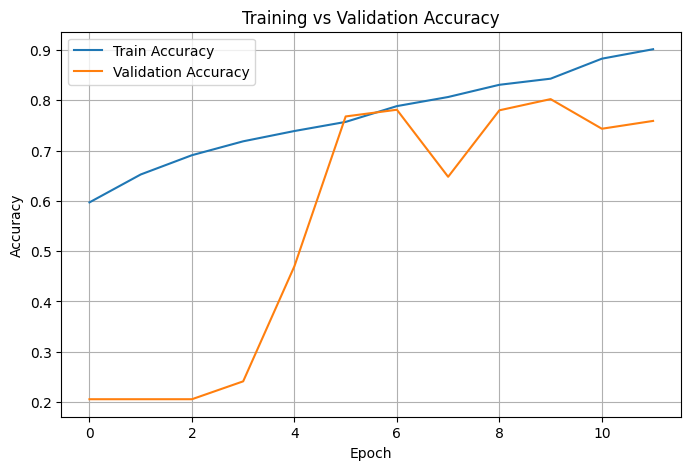

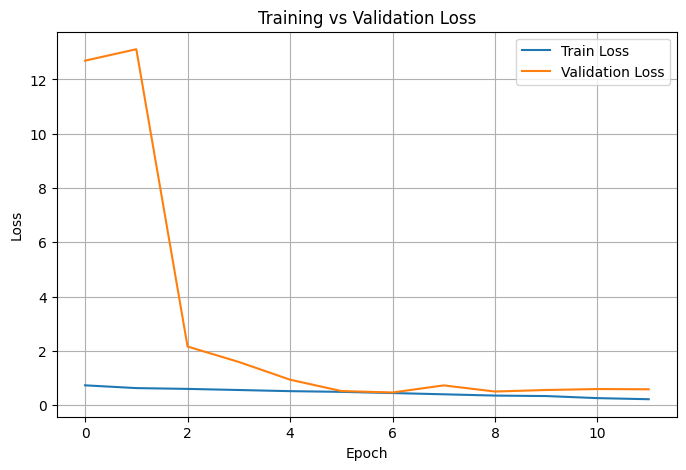

In [ ]:
# Accuracy curve
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Show results

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


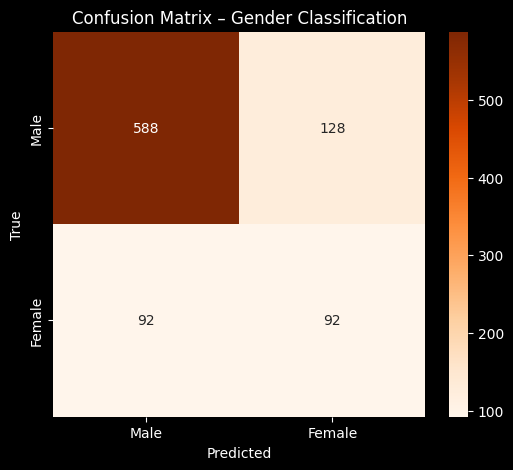


Classification Report:
              precision    recall  f1-score   support

        Male       0.86      0.82      0.84       716
      Female       0.42      0.50      0.46       184

    accuracy                           0.76       900
   macro avg       0.64      0.66      0.65       900
weighted avg       0.77      0.76      0.76       900



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Male", "Female"]

plt.style.use('dark_background')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Gender Classification")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))